In [352]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.model_selection import train_test_split
import seaborn as sns
from scipy.stats import anderson_ksamp

import torch
from torch import nn
from torch import optim
import torch.utils.data as data_utils

In [13]:
df = pd.read_csv('data/df_train.csv')
df = df.set_index('dates')

In [26]:
params = np.load('parameters/example_params.npy')
noise = np.load('data/noise.npy')

In [344]:
df.corr()

,s1,s2,s3,s4,s5,s6
s1,1.000000,0.184995,0.471392,0.416101,0.647014,0.184480
s2,0.184995,1.000000,0.307665,0.204365,0.201342,0.136610
s3,0.471392,0.307665,1.000000,0.617863,0.613491,0.529704
s4,0.416101,0.204365,0.617863,1.000000,0.601563,0.351257
s5,0.647014,0.201342,0.613491,0.601563,1.000000,0.297057
s6,0.184480,0.136610,0.529704,0.351257,0.297057,1.000000


array([[<AxesSubplot:title={'center':'s1'}>,
        <AxesSubplot:title={'center':'s2'}>],
       [<AxesSubplot:title={'center':'s3'}>,
        <AxesSubplot:title={'center':'s4'}>],
       [<AxesSubplot:title={'center':'s5'}>,
        <AxesSubplot:title={'center':'s6'}>]], dtype=object)

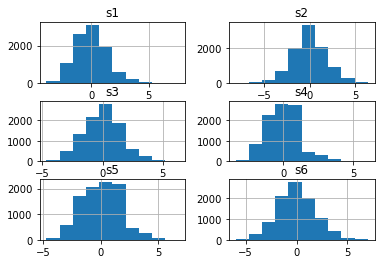

In [300]:
df.hist()

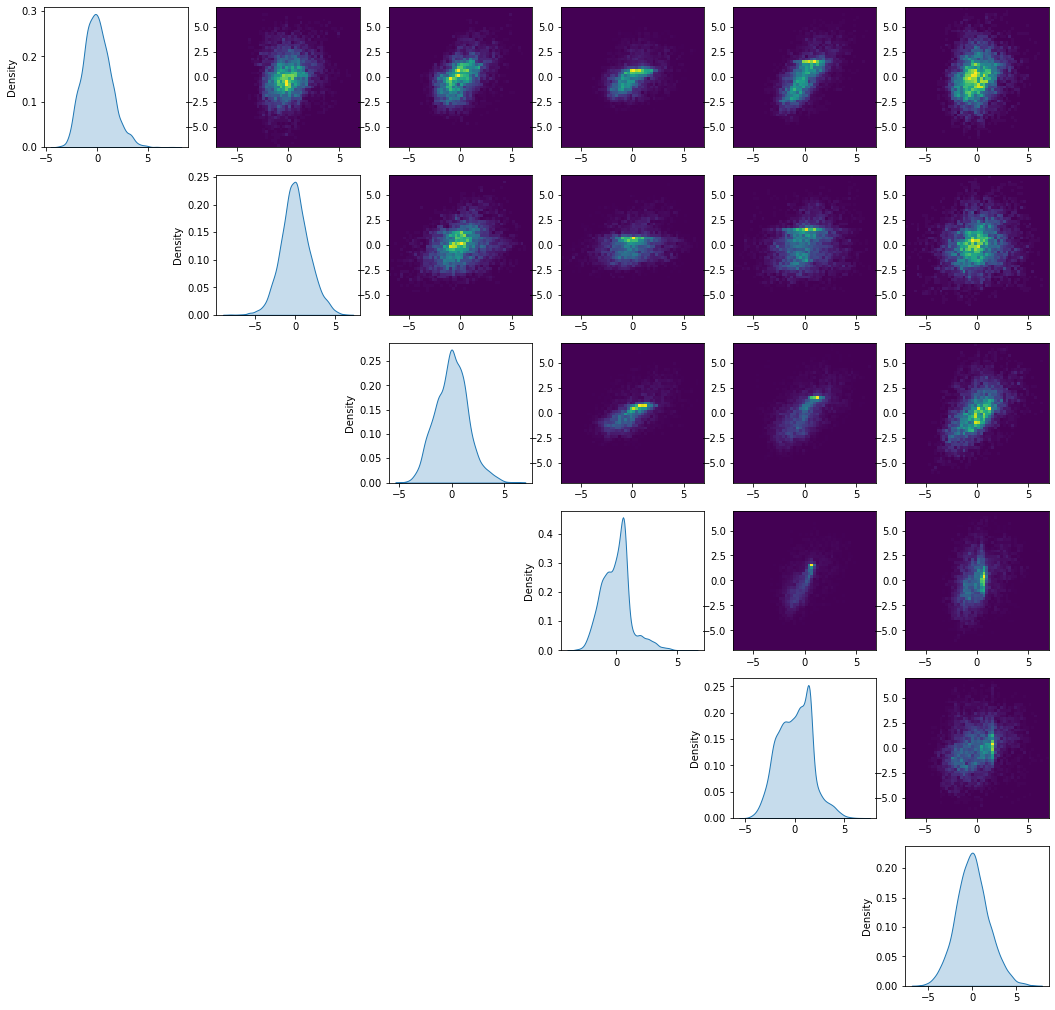

In [720]:
fig, ax = plt.subplots(nrows=6, ncols=6, figsize=(18, 18))

for i in range(6):
    for j in range(6):
        if i < j:
            ax[i][j].hist2d(df[f's{i+1}'], df[f's{j+1}'], bins=50, range=[[-7, 7], [-7, 7]])
        if i > j:
            fig.delaxes(ax[i][j])
    sns.kdeplot(data=X_train[:, i], ax=ax[i][i], fill=True)


# Normalized flows

In [608]:
# X_train, X_test = train_test_split(df[['s1', 's4', 's5']], test_size=1)
X_train = df[['s1', 's2', 's3', 's4', 's5', 's6']].to_numpy()

train = torch.tensor(X_train.astype(np.float32)) 
train_tensor = data_utils.TensorDataset(train)
train_loader = data_utils.DataLoader(dataset=train_tensor, batch_size=32, shuffle=True)

In [689]:
from nflows.transforms import MaskedAffineAutoregressiveTransform, CompositeTransform
from nflows.transforms.permutations import ReversePermutation
from nflows.distributions import StandardNormal
from nflows.flows import Flow

num_layers = 10

transforms = []
for _ in range(num_layers):
    transforms.append(ReversePermutation(features=X_train.shape[1]))
    transforms.append(MaskedAffineAutoregressiveTransform(features=X_train.shape[1], hidden_features=32))
transform = CompositeTransform(transforms)

# Define a base distribution.
base_distribution = StandardNormal(shape=[X_train.shape[1]])

# Combine into a flow.
flow = flows.Flow(transform=transform, distribution=base_distribution)
optimizer = optim.Adam(flow.parameters())


In [695]:
X_train[:, 0]

array([1.68626988, 1.74989355, 1.47520769, ..., 0.04315085, 0.06309927,
       0.23205152])

In [703]:
samples[:, 0].shape

(9618,)

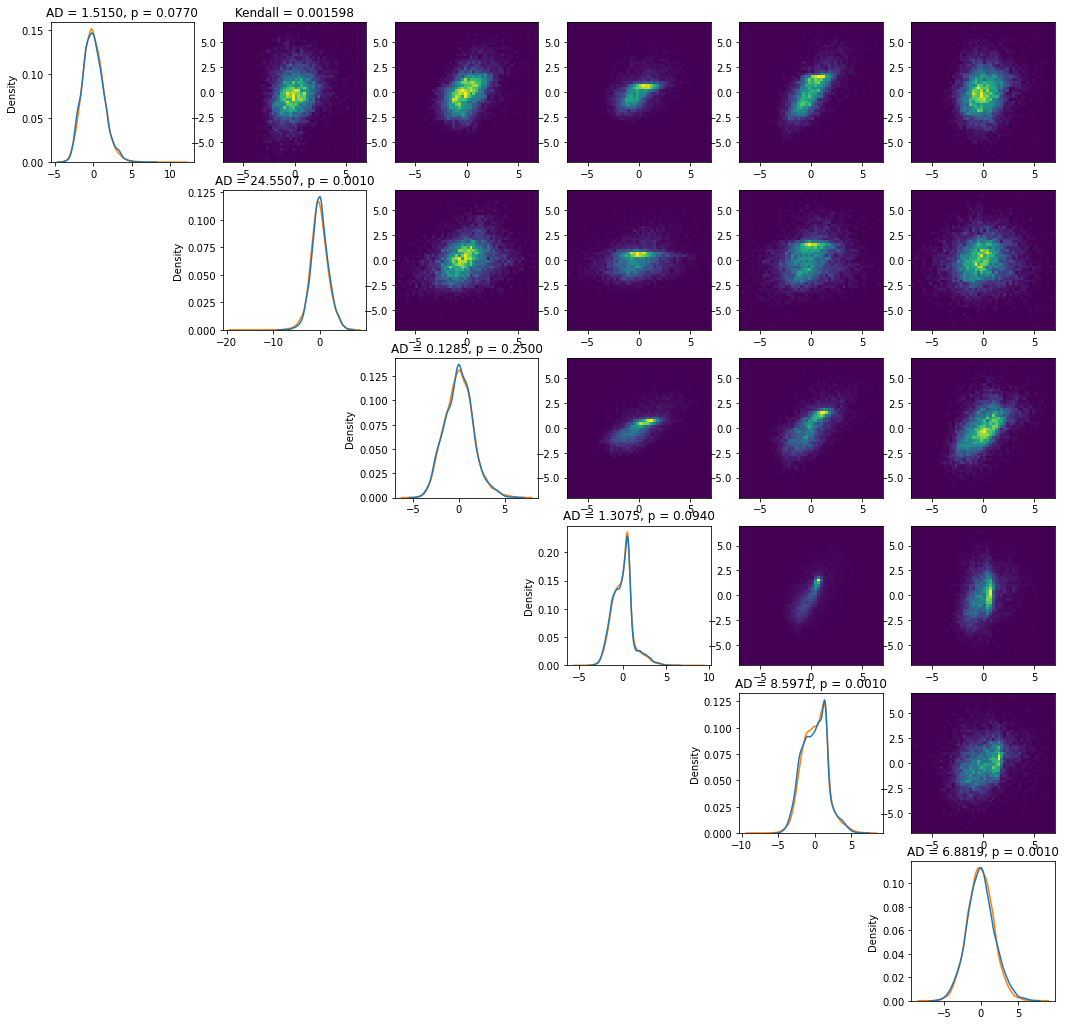

In [ ]:
num_iter = 5000

d_train = (X_train[:, None, :] > X_train[None, :, :]).prod(axis=2).mean(axis=1)
d_train = np.sort(d_train)

for batch_ndx in range(num_iter):
    
    sample = next(iter(train_loader))
    optimizer.zero_grad()
    loss = -flow.log_prob(inputs=sample[0]).mean()
    loss.backward()
    optimizer.step()
        
    if (batch_ndx) % 500 == 0:

        samples = flow.sample(len(X_train)).detach().numpy()
        
        # 2D-histograms
        
        d_sample = (samples[:, None, :] > samples[None, :, :]).prod(axis=2).mean(axis=1)
        d_sample = np.sort(d_sample)
        kendall_abs_error = np.abs(d_sample - d_train).mean()
        
        fig, ax = plt.subplots(nrows=X_train.shape[1], ncols=X_train.shape[1], figsize=(3 * X_train.shape[1], 3 * X_train.shape[1]))
        for i in range(samples.shape[1]):
            for j in range(samples.shape[1]):
                if i < j:
                    ax[i][j].hist2d(samples[:, i], samples[:, j], bins=50, range=[[-7, 7], [-7, 7]])
                if i > j:
                    fig.delaxes(ax[i][j])

            result = anderson_ksamp([samples[:, i], X_train[:, i]])
            ax[i][i].set_title(f"AD = {result.statistic:.4f}, p = {result.significance_level:.4f}")
            sns.kdeplot(data=pd.DataFrame(np.array([X_train[:, i], samples[:, i]]).T, columns=['test', 'sampled']), ax=ax[i][i])
            ax[i][i].get_legend().remove()
            
        ax[0][1].set_title(f"Kendall = {kendall_abs_error:.6f}")
        
        clear_output(wait=True)
        plt.show()
